# Visualization
Let's begin by initializing our imports and re-training the model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Reload and prepare data
df = pd.read_csv('../data/cumulative.csv')
df = df[df['koi_disposition'] != 'CANDIDATE']
df['label'] = (df['koi_disposition'] == 'CONFIRMED').astype(int)

features = ['koi_period', 'koi_depth', 'koi_duration', 'koi_prad',
            'koi_teq', 'koi_impact', 'koi_steff', 'koi_slogg', 'koi_srad']

log_features = ['koi_period', 'koi_depth', 'koi_duration', 'koi_prad', 'koi_srad']

X = df[features].copy()
for col in log_features:
    X[col] = np.log1p(X[col])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain best model (use the best params from Day 5)
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', HistGradientBoostingClassifier(random_state=42))
])

# Replace these with YOUR best params from Day 5
param_distributions = {
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__min_samples_leaf': [10, 20]
}

search = RandomizedSearchCV(
    pipeline, param_distributions, n_iter=15, scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=1
)
search.fit(X_train, y_train)
best_model = search.best_estimator_

Now that we've re-initialized our model. We also need to generate predictions. This is done via `.predict()` for the prediction (i.e 0 or 1) and also the probability via `.predict_proba()`, the model's confidence. 

Let's also make a scatter plot of all of the model's prediction where the x-axis gives us the planet's temperature in Kelvin and the y-axis gives us the planet's radius relative to Earth's. Again, because the range of planet's radius is big, we apply a logarithmic scale to squish the large values and expand on the smaller values.

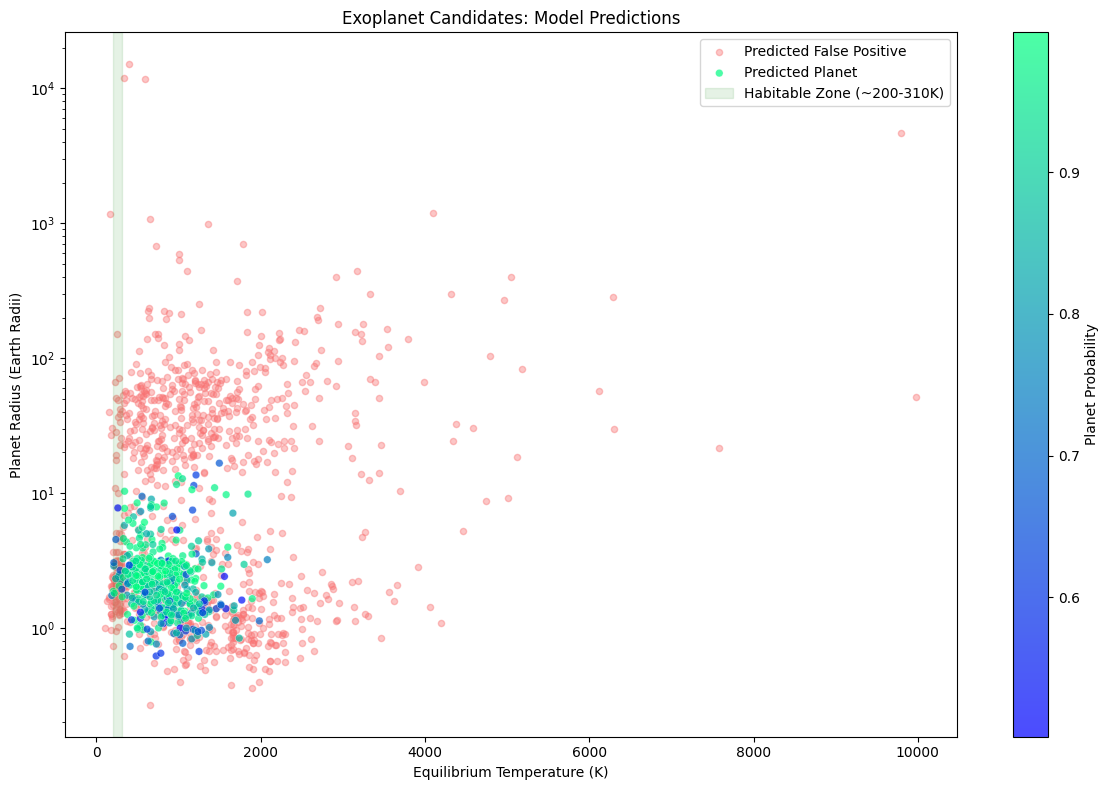

In [3]:
test_df = df.loc[X_test.index].copy()
test_df['predicted'] = best_model.predict(X_test)
test_df['probability'] = best_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(12, 8))

# Plot false positives first (behind)
fp = test_df[test_df['predicted'] == 0]
plt.scatter(fp['koi_teq'], fp['koi_prad'],
            c='#f87171', alpha=0.4, s=20, label='Predicted False Positive')

# Plot planets on top
planets = test_df[test_df['predicted'] == 1]
plt.scatter(planets['koi_teq'], planets['koi_prad'],
            c=planets['probability'], cmap='winter', alpha=0.7, s=30,
            label='Predicted Planet', edgecolors='white', linewidths=0.3)

plt.colorbar(label='Planet Probability')

# Habitable zone band
plt.axvspan(200, 310, alpha=0.1, color='green', label='Habitable Zone (~200-310K)')

plt.xlabel('Equilibrium Temperature (K)')
plt.ylabel('Planet Radius (Earth Radii)')
plt.title('Exoplanet Candidates: Model Predictions')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('hero_plot.png', dpi=150)
plt.show()

Let's see how the model go to each prediction, and what features contributed to each individual one. For that, we can use SHAP.

In [ ]:
# SHAP Setup
X_test_processed = pd.DataFrame(
    best_model[:-1].transform(X_test),
    columns=features
)

explainer = shap.Explainer(best_model.named_steps['model'], X_test_processed)
shap_values = explainer(X_test_processed, check_additivity=False)

We find the test sample where the model was most confident that it's a planet — the highest predicted probability. Then we ask SHAP to explain that prediction.

The waterfall plot you'll see has a horizontal bar for each feature. Red bars mean that feature pushed the prediction toward "planet." Blue bars mean it pushed toward "false positive." Longer bars mean stronger influence.

For a confident planet prediction, you might see something like: koi_depth has a big red bar because the transit was shallow (small objects cause shallow dips), koi_period has a red bar because the orbital period was short (easier to confirm with multiple transits), and koi_steff has a small blue bar pushing slightly the other way because the star was unusually hot.

This is powerful because you can verify it against real astrophysics. A shallow transit from a small object should be a planet. If SHAP shows the model is using that logic, it means the model learned real science, not just random number patterns.

Probability: 0.9986
Actual label: 1


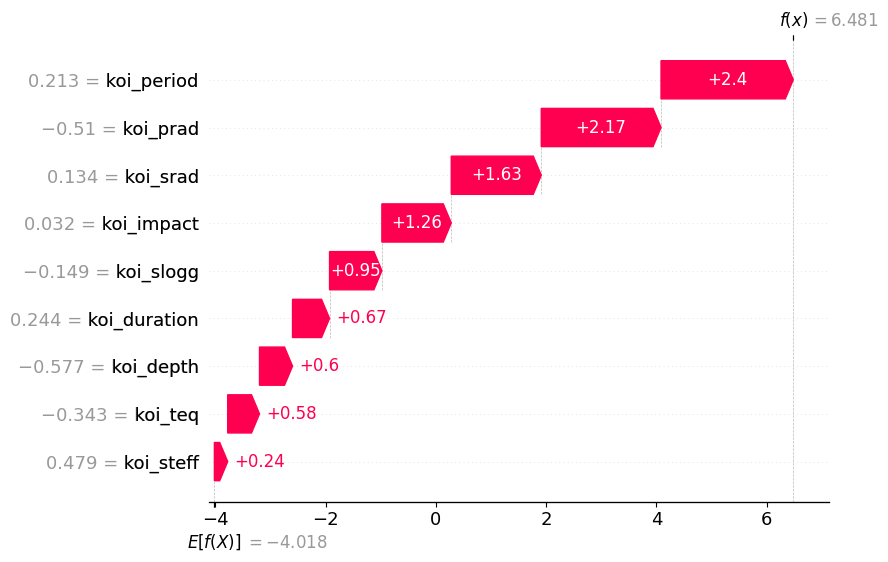

In [6]:
# Find a confident correct planet prediction
planet_indices = y_test[y_test == 1].index
test_probs = best_model.predict_proba(X_test)[:, 1]
confident_planet_idx = np.argmax(test_probs)

print(f"Probability: {test_probs[confident_planet_idx]:.4f}")
print(f"Actual label: {y_test.iloc[confident_planet_idx]}")

shap.plots.waterfall(shap_values[confident_planet_idx])

Same thing but for the model's most confident false positive prediction. The waterfall will look like the opposite: deep transit pushing toward false positive, high impact parameter pushing toward false positive, large estimated radius pushing toward false positive.
When you compare this plot next to the planet one, you can see the model's complete decision logic in both directions.

Probability: 0.0000
Actual label: 0


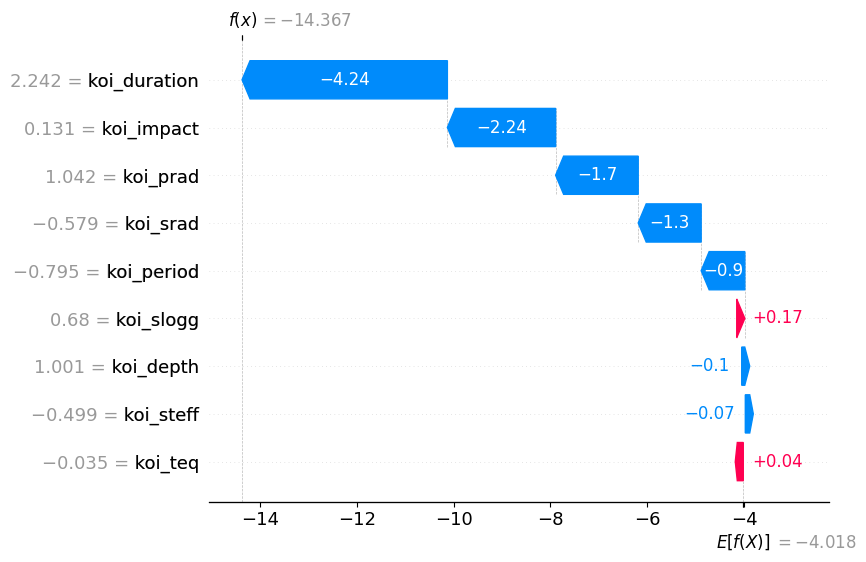

In [7]:
confident_fp_idx = np.argmin(test_probs)

print(f"Probability: {test_probs[confident_fp_idx]:.4f}")
print(f"Actual label: {y_test.iloc[confident_fp_idx]}")

shap.plots.waterfall(shap_values[confident_fp_idx])

Now, we find a real planet that the model missed (i.e it said "false positive" but the truth was "planet.")
The waterfall shows us exactly why the model was fooled. Maybe this particular planet had a really deep transit, deeper than most planets. The model saw that deep transit and thought "that looks like an eclipsing binary star, not a planet." But it was actually a large planet orbiting a small star, which can produce deep transits even though it's a real planet.
Or maybe the impact parameter was slightly above 1 due to measurement noise. The model learned that values above 1 usually mean a bad signal fit, so it classified it as false positive. But in this case the measurement was just slightly off and the planet was real.

Probability: 0.3187
Actual label: 1


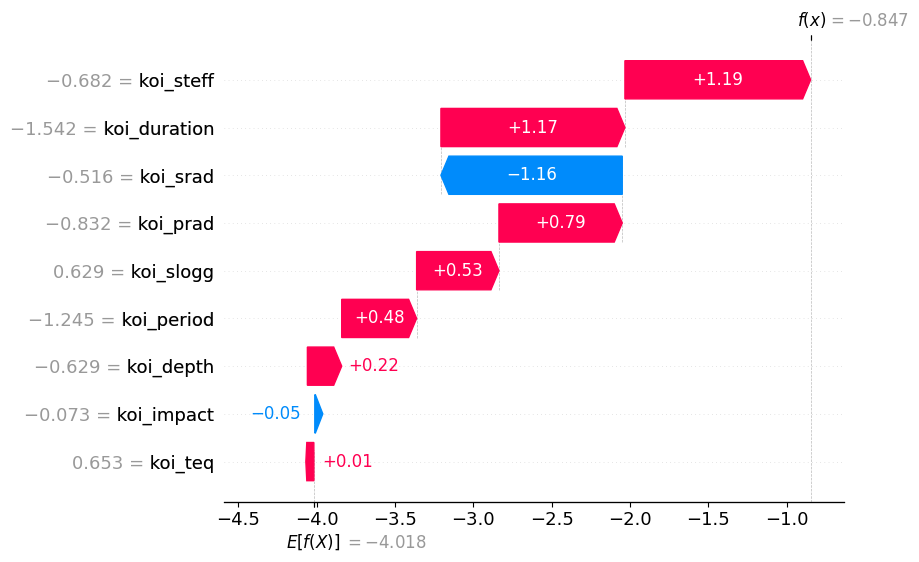

In [8]:
# Find a false negative (actual planet predicted as false positive)
false_negatives = (y_test == 1) & (best_model.predict(X_test) == 0)
fn_indices = np.where(false_negatives)[0]
if len(fn_indices) > 0:
    fn_idx = fn_indices[0]
    print(f"Probability: {test_probs[fn_idx]:.4f}")
    print(f"Actual label: {y_test.iloc[fn_idx]}")
    shap.plots.waterfall(shap_values[fn_idx])

Simple bookkeeping. We flag every prediction as correct or wrong, then count the two types of errors separately.

False positives (model said planet but it wasn't): these represent wasted telescope time. If astronomers used this model to prioritize follow-up observations, these would be signals they investigate for nothing.

False negatives (model said false positive but it was actually a planet): these represent missed discoveries. Real planets that got overlooked.

The balance between these two numbers tells you if the model has a bias. If it makes way more false positives than false negatives, it's too trigger-happy. If the opposite, it's too cautious. Our model's roughly equal split (63 vs 64) means it's balanced, meaning that it doesn't favor one type of mistake over the other.

We then plot histograms comparing feature values for correct predictions versus errors. This shows you if errors cluster at specific feature ranges.
If you see errors bunching up at moderate transit depths — not super shallow (clearly planet) and not super deep (clearly false positive) but somewhere in the middle — that makes perfect sense. The ambiguous middle ground is where the model has the hardest time deciding because both classes overlap there. That's exactly what our EDA on Day 2 showed.

Total errors: 127
False positives (predicted planet, actually not): 63
False negatives (predicted false pos, actually planet): 64


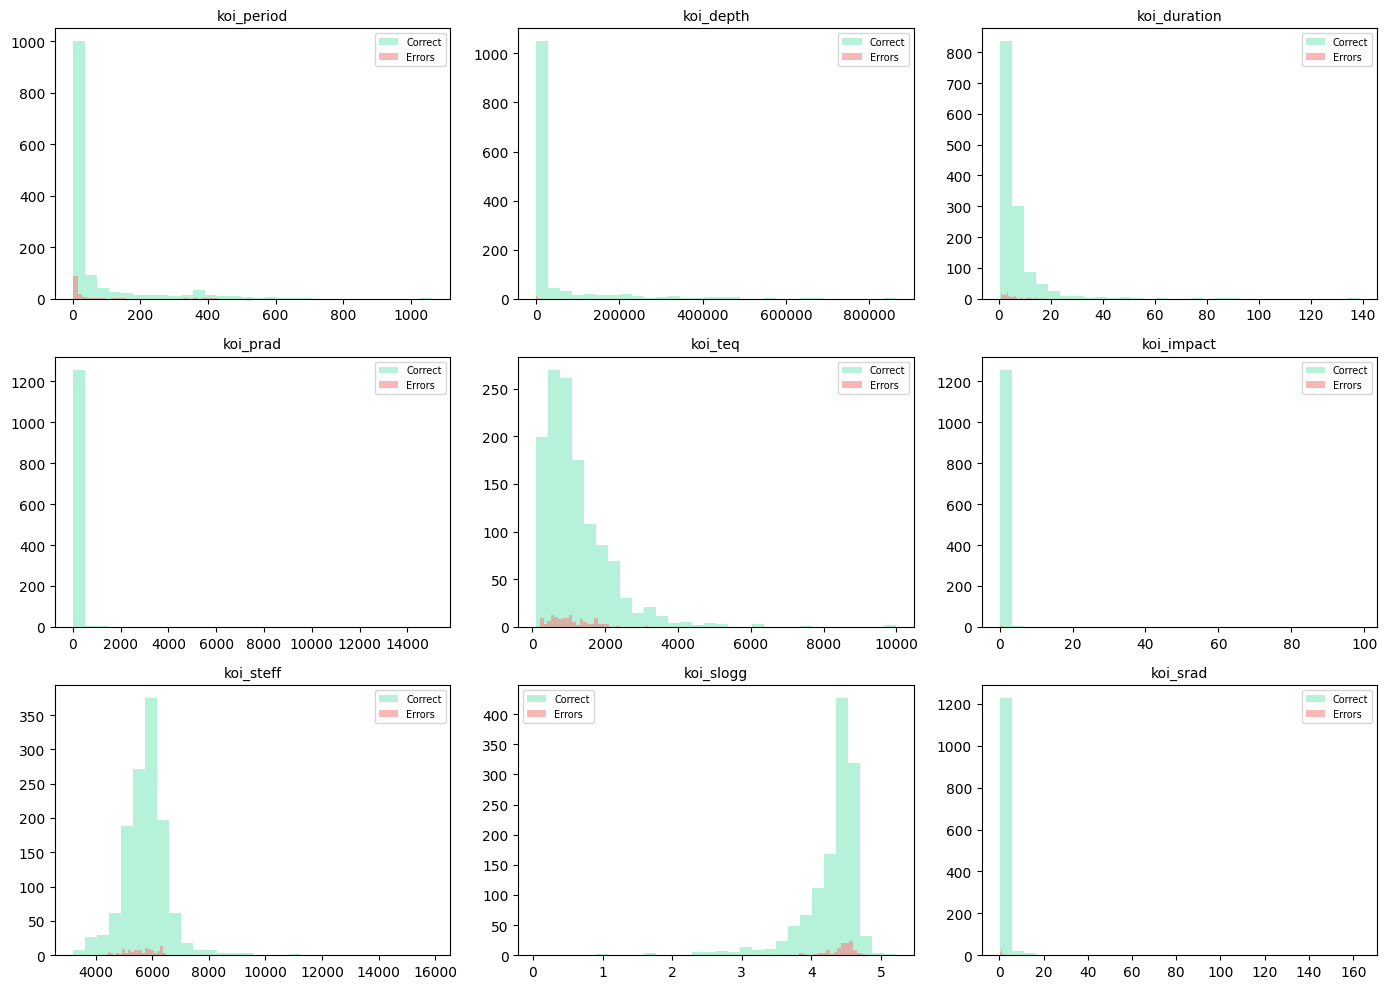

In [9]:
test_df['correct'] = test_df['predicted'] == test_df['label']

errors = test_df[test_df['correct'] == False]
correct = test_df[test_df['correct'] == True]

print(f"Total errors: {len(errors)}")
print(f"False positives (predicted planet, actually not): "
      f"{len(errors[errors['predicted'] == 1])}")
print(f"False negatives (predicted false pos, actually planet): "
      f"{len(errors[errors['predicted'] == 0])}")

# Compare feature distributions for correct vs incorrect predictions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), features):
    ax.hist(correct[col].dropna(), bins=30, alpha=0.5, color='#6ee7b7', label='Correct')
    ax.hist(errors[col].dropna(), bins=30, alpha=0.5, color='#f87171', label='Errors')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150)
plt.show()